Data Cleaning

In [2]:
import pandas as pd
df = pd.read_csv('Customer-Churn-Records.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [3]:
print("Shape before:", df.shape)
print("Columns:", df.columns.tolist())

Shape before: (10000, 18)
Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Card Type', 'Point Earned']


In [4]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)
print("Shape after:", df.shape)
df.head()

Shape after: (10000, 15)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [5]:
print(df.isnull().sum())

CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64


In [6]:
print(df.isnull().sum() / len(df) * 100)

CreditScore           0.0
Geography             0.0
Gender                0.0
Age                   0.0
Tenure                0.0
Balance               0.0
NumOfProducts         0.0
HasCrCard             0.0
IsActiveMember        0.0
EstimatedSalary       0.0
Exited                0.0
Complain              0.0
Satisfaction Score    0.0
Card Type             0.0
Point Earned          0.0
dtype: float64


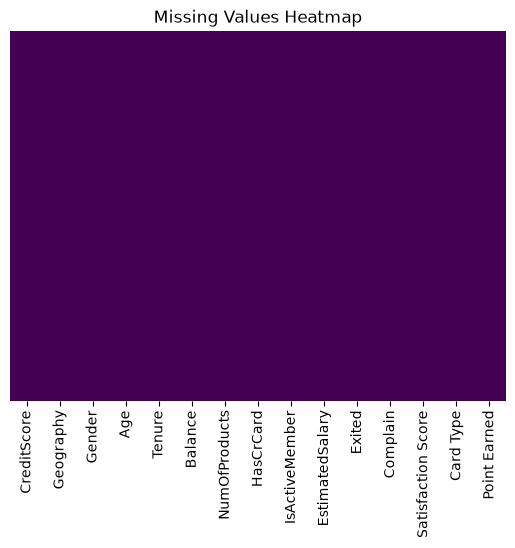

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [8]:
print("Duplicate rows:", df.duplicated().sum())
df[df.duplicated()]
df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (10000, 15)


In [9]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


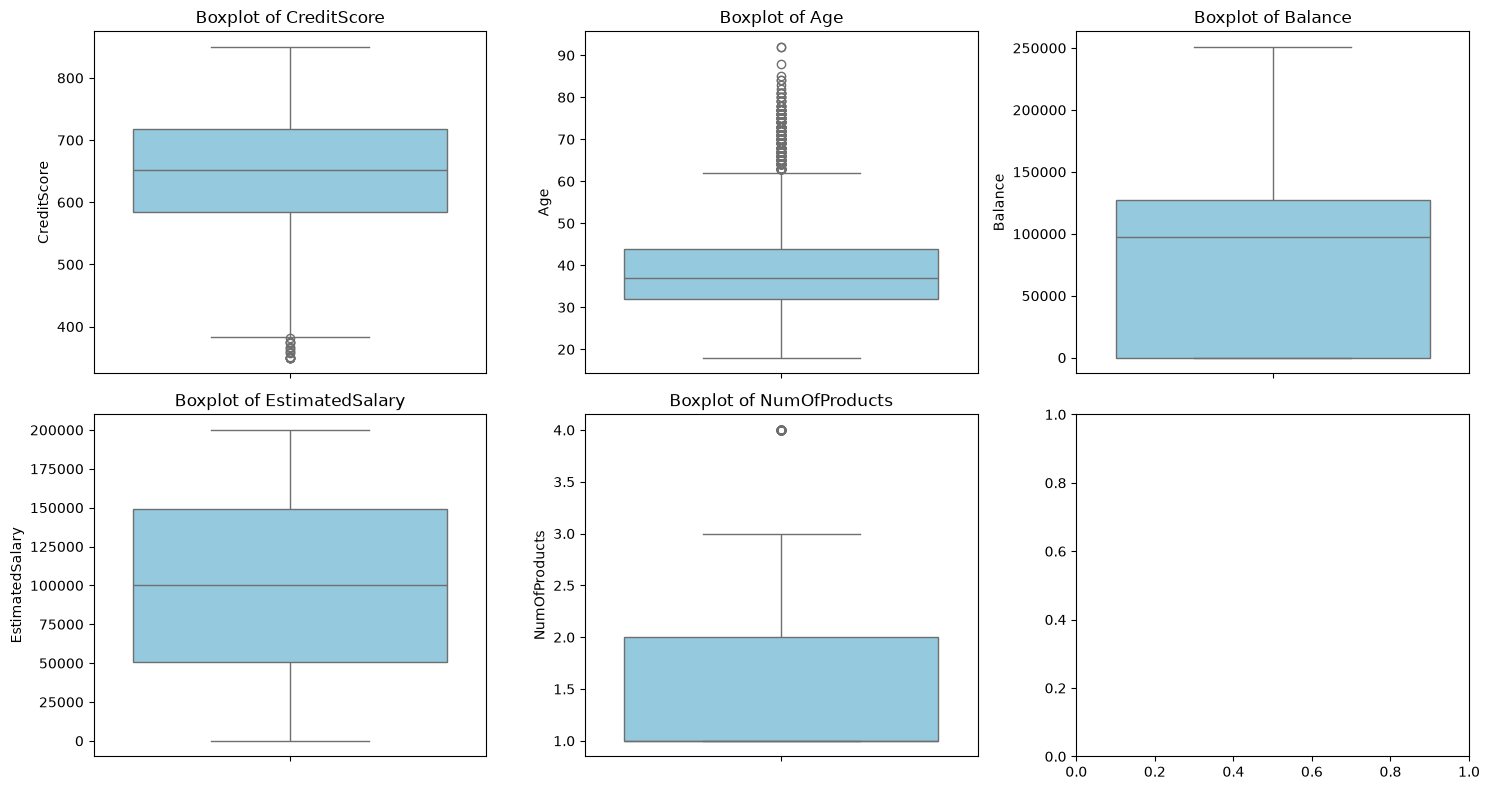

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
columns_to_check = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'NumOfProducts']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(columns_to_check):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [11]:
print("CreditScore range:", df['CreditScore'].min(), "-", df['CreditScore'].max())
print("Age range:", df['Age'].min(), "-", df['Age'].max())
print("NumOfProducts range:", df['NumOfProducts'].min(), "-", df['NumOfProducts'].max())

CreditScore range: 350 - 850
Age range: 18 - 92
NumOfProducts range: 1 - 4


In [12]:
print("Customers above age 85:", (df['Age'] > 85).sum())

Customers above age 85: 3


In [13]:
df['Age'] = df['Age'].clip(upper=85)
print("New Age range:", df['Age'].min(), "-", df['Age'].max())

New Age range: 18 - 85


In [14]:
print(df['Exited'].value_counts())
print("\nPercentage:")
print(df['Exited'].value_counts(normalize=True) * 100)

Exited
0    7962
1    2038
Name: count, dtype: int64

Percentage:
Exited
0    79.62
1    20.38
Name: proportion, dtype: float64


C:\Users\abdul\AppData\Local\Temp\ipykernel_16272\1081511045.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=df, palette='viridis')


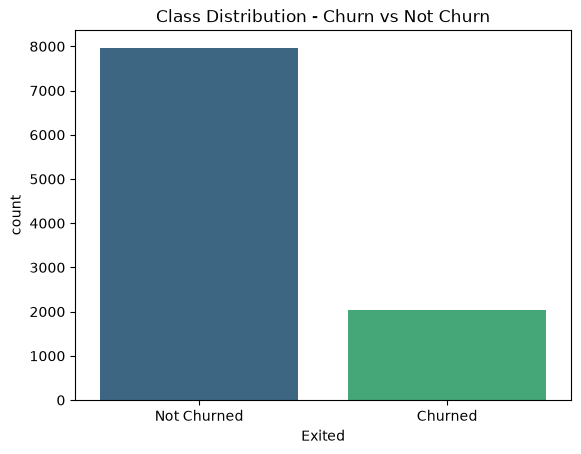

In [15]:
sns.countplot(x='Exited', data=df, palette='viridis')
plt.title('Class Distribution - Churn vs Not Churn')
plt.xticks([0, 1], ['Not Churned', 'Churned'])
plt.show()

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
print(df['Gender'].value_counts())

Gender
1    5457
0    4543
Name: count, dtype: int64


In [17]:
df = pd.get_dummies(df, columns=['Geography', 'Card Type'], drop_first=True)
print(df.shape)
df.head()

(10000, 18)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned,Geography_Germany,Geography_Spain,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,2,464,False,False,False,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,1,3,456,False,True,False,False,False
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1,3,377,False,False,False,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,5,350,False,False,True,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,5,425,False,True,True,False,False


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols_to_scale = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'Point Earned']

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned,Geography_Germany,Geography_Spain,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,-0.326221,0,0.293903,2,-1.225848,1,1,1,0.021886,1,1,2,-0.630839,False,False,False,False,False
1,-0.440036,0,0.198477,1,0.117350,1,0,1,0.216534,0,1,3,-0.666251,False,True,False,False,False
2,-1.536794,0,0.293903,8,1.333053,3,1,0,0.240687,1,1,3,-1.015942,False,False,False,False,False
3,0.501521,0,0.007625,1,-1.225848,2,0,0,-0.108918,0,0,5,-1.135457,False,False,True,False,False
4,2.063884,0,0.389329,2,0.785728,1,1,1,-0.365276,0,0,5,-0.803472,False,True,True,False,False


EDA

In [20]:
#(Univariate Analysis)

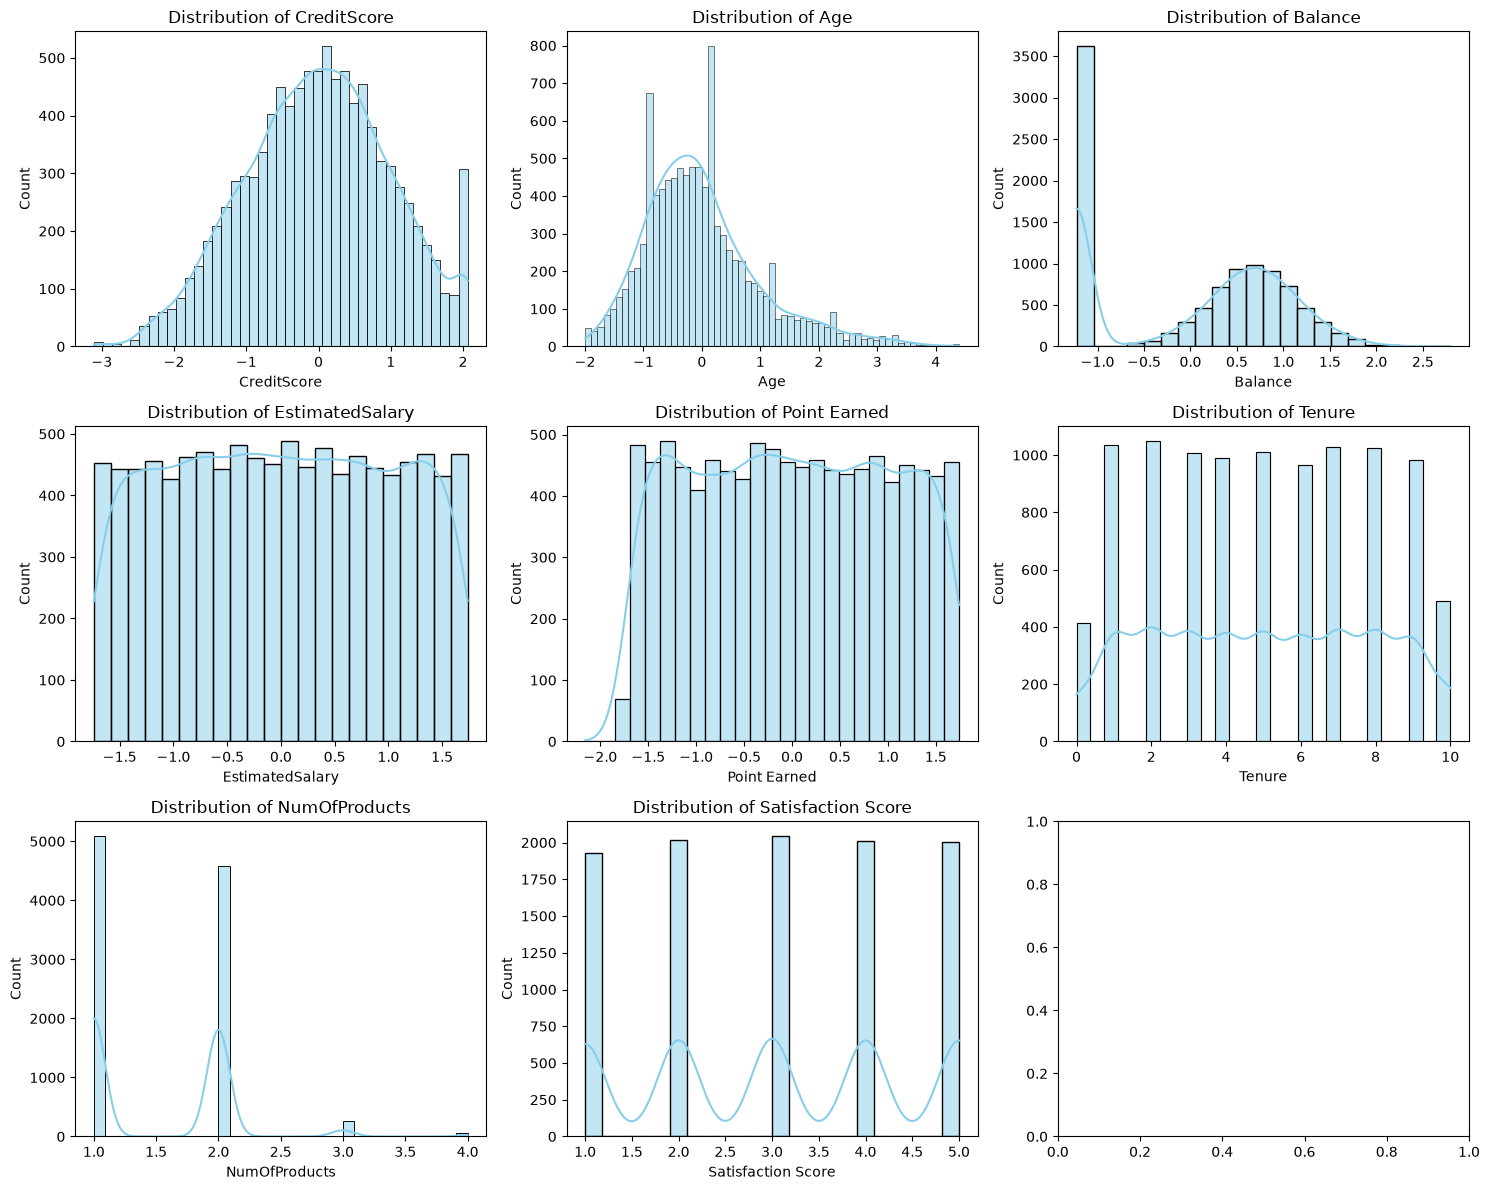

In [21]:
numerical_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'Point Earned', 
                  'Tenure', 'NumOfProducts', 'Satisfaction Score']
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], ax=axes[i], kde=True, color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

C:\Users\abdul\AppData\Local\Temp\ipykernel_16272\3678455712.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=df, palette='viridis')


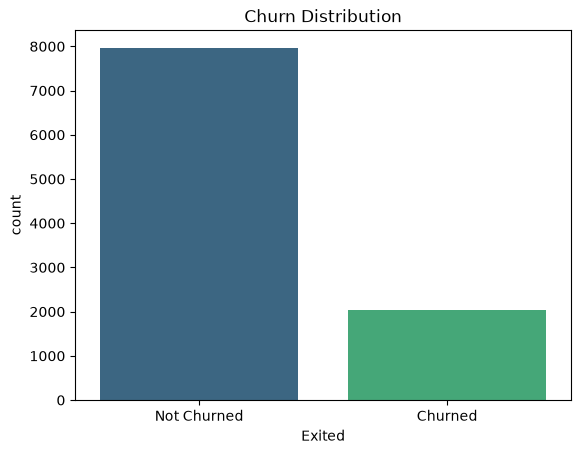

In [22]:
sns.countplot(x='Exited', data=df, palette='viridis')
plt.title('Churn Distribution')
plt.xticks([0, 1], ['Not Churned', 'Churned'])
plt.show()

C:\Users\abdul\AppData\Local\Temp\ipykernel_16272\3020386917.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='viridis')


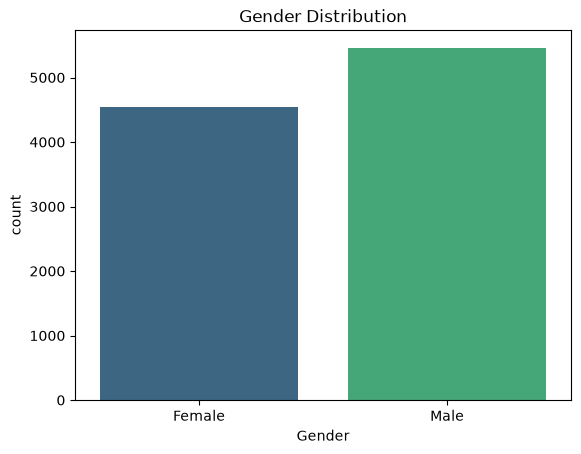

In [23]:
sns.countplot(x='Gender', data=df, palette='viridis')
plt.title('Gender Distribution')
plt.xticks([0, 1], ['Female', 'Male'])
plt.show()

In [24]:
#(Bivariate Analysis)

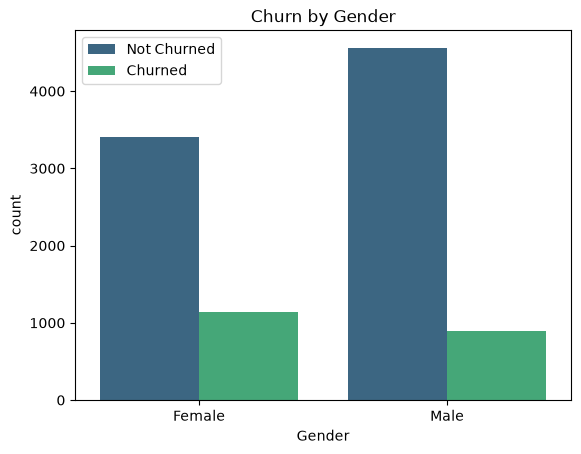

In [25]:
sns.countplot(x='Gender', hue='Exited', data=df, palette='viridis')
plt.title('Churn by Gender')
plt.xticks([0, 1], ['Female', 'Male'])
plt.legend(['Not Churned', 'Churned'])
plt.show()

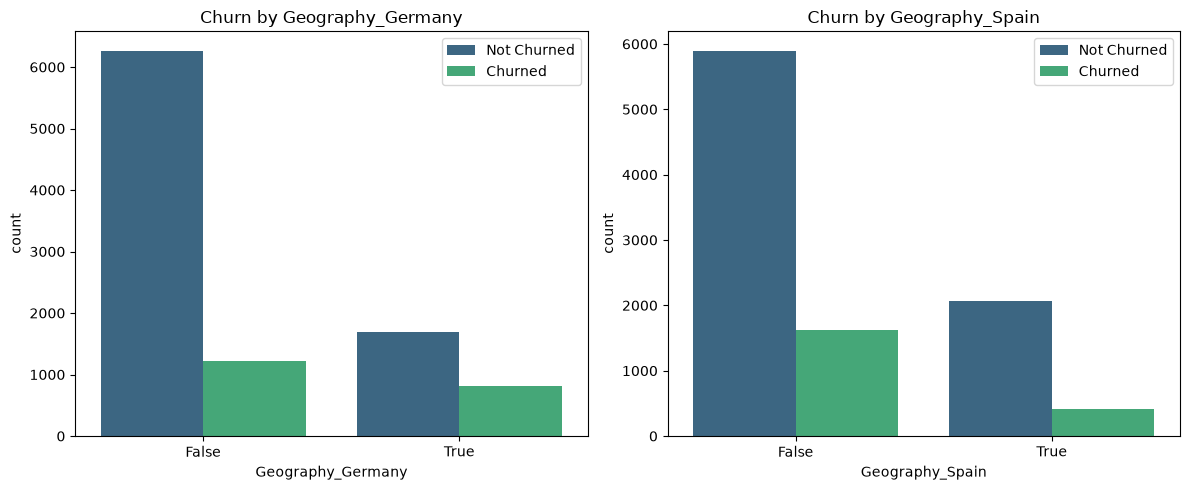

In [26]:
geography_cols = ['Geography_Germany', 'Geography_Spain']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, col in enumerate(geography_cols):
    sns.countplot(x=col, hue='Exited', data=df, palette='viridis', ax=axes[i])
    axes[i].set_title(f'Churn by {col}')
    axes[i].legend(['Not Churned', 'Churned'])

plt.tight_layout()
plt.show()

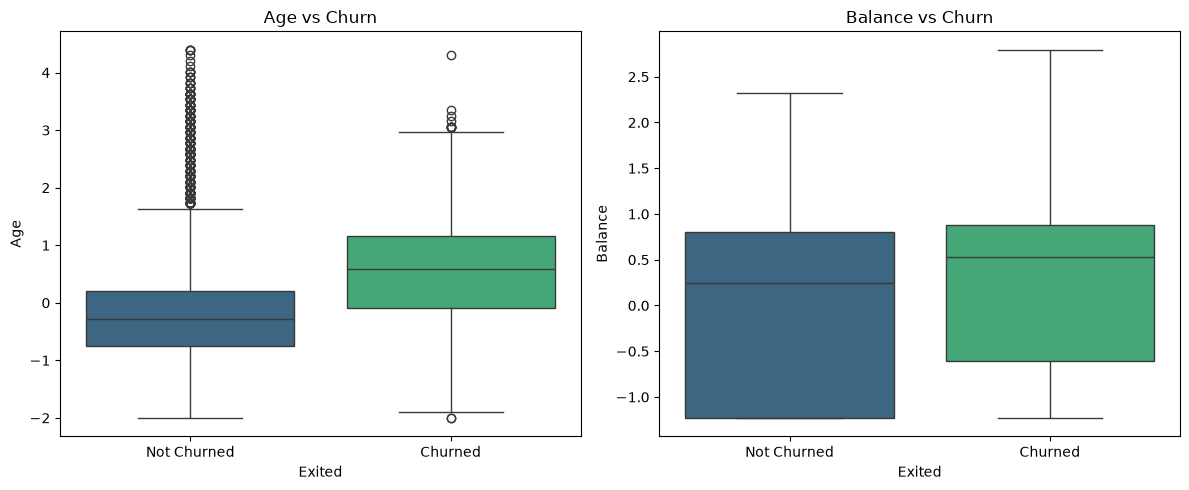

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='Exited', y='Age', data=df, hue='Exited', legend=False, palette='viridis', ax=axes[0])
axes[0].set_title('Age vs Churn')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Not Churned', 'Churned'])

sns.boxplot(x='Exited', y='Balance', data=df, hue='Exited', legend=False, palette='viridis', ax=axes[1])
axes[1].set_title('Balance vs Churn')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Not Churned', 'Churned'])

plt.tight_layout()
plt.show()

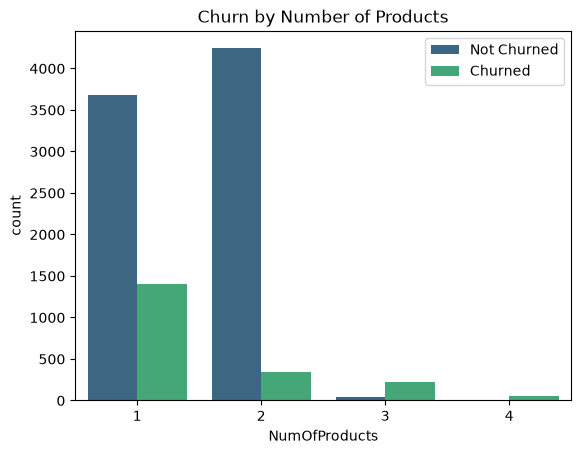

In [28]:
sns.countplot(x='NumOfProducts', hue='Exited', data=df, palette='viridis')
plt.title('Churn by Number of Products')
plt.legend(['Not Churned', 'Churned'])
plt.show()

In [29]:
#(Correlation Analysis)

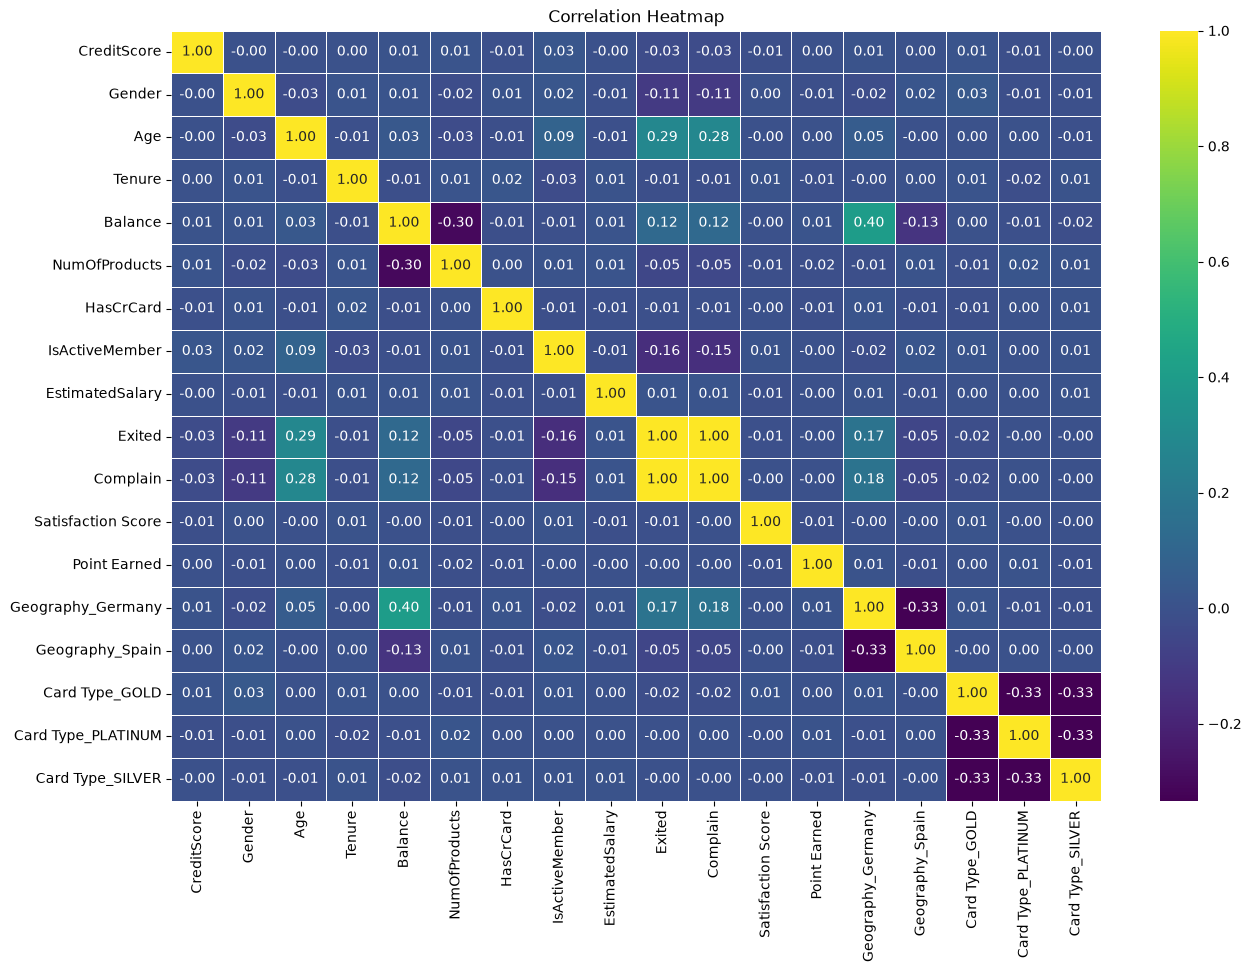

In [30]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='viridis', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [31]:
#(Churn Patterns)

In [32]:
# Active vs Inactive Members
print("=== Active vs Inactive Churn Rate ===")
print(df.groupby('IsActiveMember')['Exited'].mean() * 100)

# Has Credit Card vs Not
print("\n=== Credit Card Holders Churn Rate ===")
print(df.groupby('HasCrCard')['Exited'].mean() * 100)

# Satisfaction Score vs Churn
print("\n=== Satisfaction Score vs Churn Rate ===")
print(df.groupby('Satisfaction Score')['Exited'].mean() * 100)

# Complain vs Churn
print("\n=== Complain vs Churn Rate ===")
print(df.groupby('Complain')['Exited'].mean() * 100)

# Card Type vs Churn
print("\n=== Card Type vs Churn Rate ===")
card_type_cols = ['Card Type_GOLD', 'Card Type_PLATINUM', 'Card Type_SILVER']
for col in card_type_cols:
    print(f"{col}: {df[df[col] == 1]['Exited'].mean() * 100:.2f}%")
print(f"Card Type_DIAMOND: {df[(df['Card Type_GOLD'] == 0) & (df['Card Type_PLATINUM'] == 0) & (df['Card Type_SILVER'] == 0)]['Exited'].mean() * 100:.2f}%")

=== Active vs Inactive Churn Rate ===
IsActiveMember
0    26.871520
1    14.269074
Name: Exited, dtype: float64

=== Credit Card Holders Churn Rate ===
HasCrCard
0    20.814941
1    20.198441
Name: Exited, dtype: float64

=== Satisfaction Score vs Churn Rate ===
Satisfaction Score
1    20.031056
2    21.797418
3    19.637610
4    20.617530
5    19.810379
Name: Exited, dtype: float64

=== Complain vs Churn Rate ===
Complain
0     0.050277
1    99.510763
Name: Exited, dtype: float64

=== Card Type vs Churn Rate ===
Card Type_GOLD: 19.26%
Card Type_PLATINUM: 20.36%
Card Type_SILVER: 20.11%
Card Type_DIAMOND: 21.78%


Feature Engineering

In [34]:
# Balance Per Product
df['Balance_Per_Product'] = df['Balance'] / df['NumOfProducts']

# Age Group
df['Age_Group'] = pd.cut(df['Age'], bins=3, labels=['Young', 'Middle', 'Senior'])
df['Age_Group'] = LabelEncoder().fit_transform(df['Age_Group'])

# Is Zero Balance
df['Is_Zero_Balance'] = (df['Balance'] == df['Balance'].min()).astype(int)

# Complain & Inactive
df['Complain_Inactive'] = ((df['Complain'] == 1) & (df['IsActiveMember'] == 0)).astype(int)

# Germany & Female
df['Germany_Female'] = ((df['Geography_Germany'] == 1) & (df['Gender'] == 0)).astype(int)

# Products & Active
df['Products_Active'] = df['NumOfProducts'] * df['IsActiveMember']

print("New features created successfully!")
print("Shape after adding features:", df.shape)

New features created successfully!
Shape after adding features: (10000, 24)


In [35]:
df.drop(columns=[
    'Satisfaction Score',
    'HasCrCard',
    'Card Type_GOLD',
    'Card Type_PLATINUM',
    'Card Type_SILVER',
    'EstimatedSalary'
], inplace=True)

print("Useless features dropped!")
print("Shape after dropping features:", df.shape)

Useless features dropped!
Shape after dropping features: (10000, 18)


In [36]:
print("=== Final Dataset Shape ===")
print(df.shape)

print("\n=== Final Columns ===")
print(df.columns.tolist())

print("\n=== First 5 Rows ===")
df.head()

=== Final Dataset Shape ===
(10000, 18)

=== Final Columns ===
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'IsActiveMember', 'Exited', 'Complain', 'Point Earned', 'Geography_Germany', 'Geography_Spain', 'Balance_Per_Product', 'Age_Group', 'Is_Zero_Balance', 'Complain_Inactive', 'Germany_Female', 'Products_Active']

=== First 5 Rows ===


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,IsActiveMember,Exited,Complain,Point Earned,Geography_Germany,Geography_Spain,Balance_Per_Product,Age_Group,Is_Zero_Balance,Complain_Inactive,Germany_Female,Products_Active
0,-0.326221,0,0.293903,2,-1.225848,1,1,1,1,-0.630839,False,False,-1.225848,0,1,0,0,1
1,-0.440036,0,0.198477,1,0.117350,1,1,0,1,-0.666251,False,True,0.117350,0,0,0,0,1
2,-1.536794,0,0.293903,8,1.333053,3,0,1,1,-1.015942,False,False,0.444351,0,0,1,0,0
3,0.501521,0,0.007625,1,-1.225848,2,0,0,0,-1.135457,False,False,-0.612924,2,1,0,0,0
4,2.063884,0,0.389329,2,0.785728,1,1,0,0,-0.803472,False,True,0.785728,0,0,0,0,1


Data Splitting 

In [38]:
X = df.drop(columns=['Exited'])
y = df['Exited']

print("Features shape (X):", X.shape)
print("Target shape (y):", y.shape)

Features shape (X): (10000, 17)
Target shape (y): (10000,)


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 8000 rows
Testing set size: 2000 rows


In [40]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("=== Class Distribution Before SMOTE ===")
print(y_train.value_counts())

print("\n=== Class Distribution After SMOTE ===")
print(y_train_balanced.value_counts())

=== Class Distribution Before SMOTE ===
Exited
0    6370
1    1630
Name: count, dtype: int64

=== Class Distribution After SMOTE ===
Exited
0    6370
1    6370
Name: count, dtype: int64


In [41]:
import mlflow

mlflow.set_experiment("Bank_Customer_Churn_Prediction")

print("MLflow experiment tracker initialized successfully!")

MLflow experiment tracker initialized successfully!


In [42]:
X_real = df.drop(columns=['Exited', 'Complain', 'Complain_Inactive'])
y_real = df['Exited']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42, stratify=y_real
)

X_train_bal_r, y_train_bal_r = smote.fit_resample(X_train_r, y_train_r)

print("Leaking features dropped. New feature shape:", X_real.shape)

Leaking features dropped. New feature shape: (10000, 15)


In [47]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

with mlflow.start_run(run_name="XGBoost_No_Leakage"):
    xgb_model_real = XGBClassifier(random_state=42, eval_metric='logloss')
    xgb_model_real.fit(X_train_bal_r, y_train_bal_r)
    
    y_pred_r = xgb_model_real.predict(X_test_r)
    y_proba_r = xgb_model_real.predict_proba(X_test_r)[:, 1]
    
    roc_auc_r = roc_auc_score(y_test_r, y_proba_r)
    
    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("sampling_strategy", "SMOTE")
    mlflow.log_param("features_used", "Excluded Complain columns")
    mlflow.log_metric("roc_auc", roc_auc_r)
    
    print(f"Realistic XGBoost Test ROC-AUC Score: {roc_auc_r:.4f}\n")
    print("Realistic Classification Report:")
    print(classification_report(y_test_r, y_pred_r))

Realistic XGBoost Test ROC-AUC Score: 0.8583

Realistic Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1592
           1       0.61      0.66      0.63       408

    accuracy                           0.84      2000
   macro avg       0.76      0.77      0.77      2000
weighted avg       0.85      0.84      0.85      2000



In [48]:
from lightgbm import LGBMClassifier

with mlflow.start_run(run_name="LightGBM_Baseline_SMOTE"):
    lgb_model = LGBMClassifier(random_state=42, verbose=-1)
    lgb_model.fit(X_train_bal_r, y_train_bal_r)
    
    y_pred_lgb = lgb_model.predict(X_test_r)
    y_proba_lgb = lgb_model.predict_proba(X_test_r)[:, 1]
    
    roc_auc_lgb = roc_auc_score(y_test_r, y_proba_lgb)
    
    mlflow.log_param("model_type", "LightGBM")
    mlflow.log_param("sampling_strategy", "SMOTE")
    mlflow.log_metric("roc_auc", roc_auc_lgb)
    
    print(f"LightGBM Test ROC-AUC Score: {roc_auc_lgb:.4f}\n")
    print("LightGBM Classification Report:")
    print(classification_report(y_test_r, y_pred_lgb))

LightGBM Test ROC-AUC Score: 0.8753

LightGBM Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      1592
           1       0.64      0.65      0.64       408

    accuracy                           0.85      2000
   macro avg       0.77      0.78      0.77      2000
weighted avg       0.85      0.85      0.85      2000



C:\Users\abdul\AppData\Local\Temp\ipykernel_16272\1785637741.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=xgb_feats, palette='viridis')


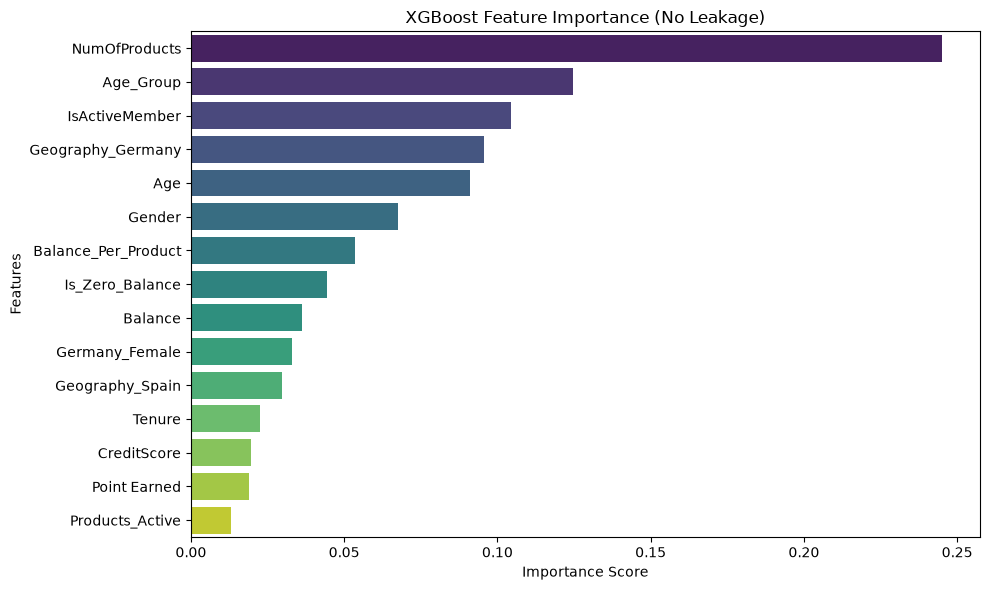

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = xgb_model_real.feature_importances_
feature_names = X_real.columns

xgb_feats = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
xgb_feats = xgb_feats.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=xgb_feats, palette='viridis')
plt.title('XGBoost Feature Importance (No Leakage)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [50]:
import shap

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer(X_test_r)

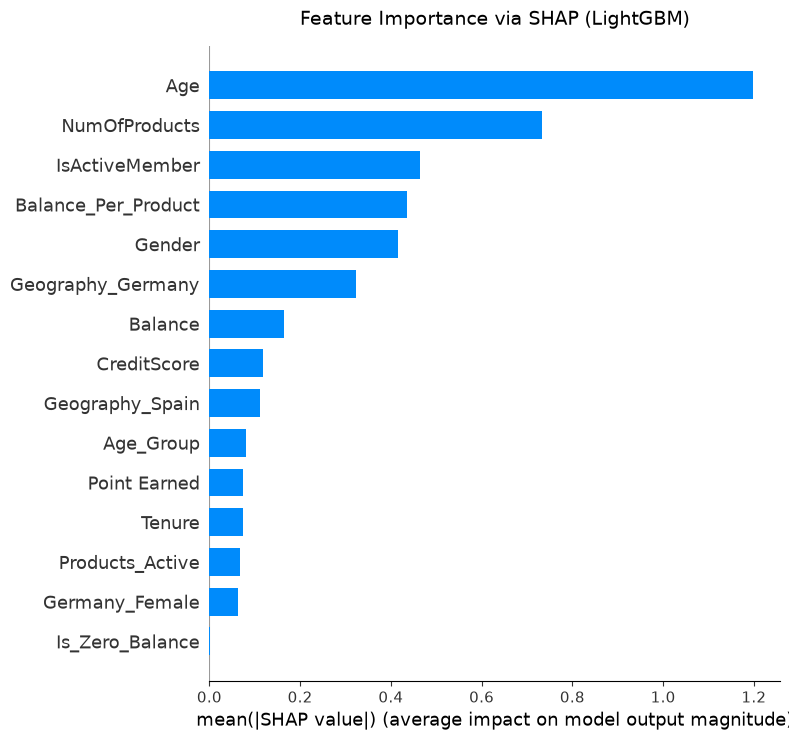

In [51]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_r, plot_type="bar", show=False)
plt.title("Feature Importance via SHAP (LightGBM)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

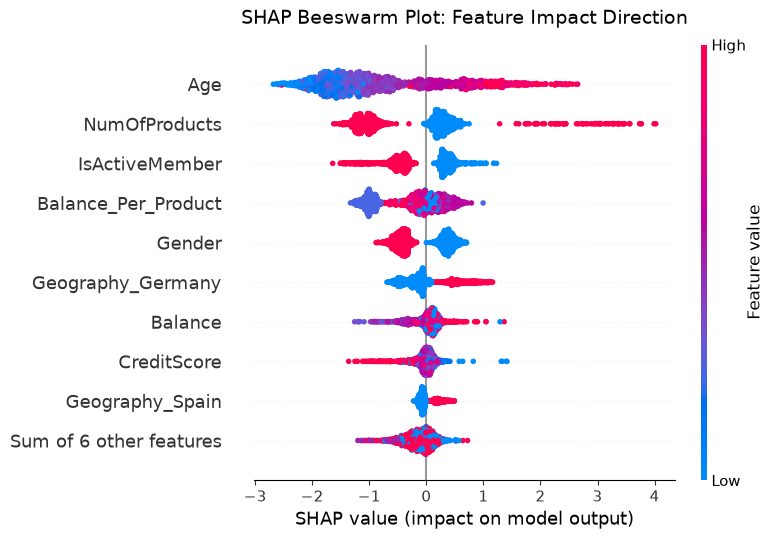

In [52]:
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, show=False)
plt.title("SHAP Beeswarm Plot: Feature Impact Direction", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [53]:
import joblib

joblib.dump(lgb_model, 'lightgbm_churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!


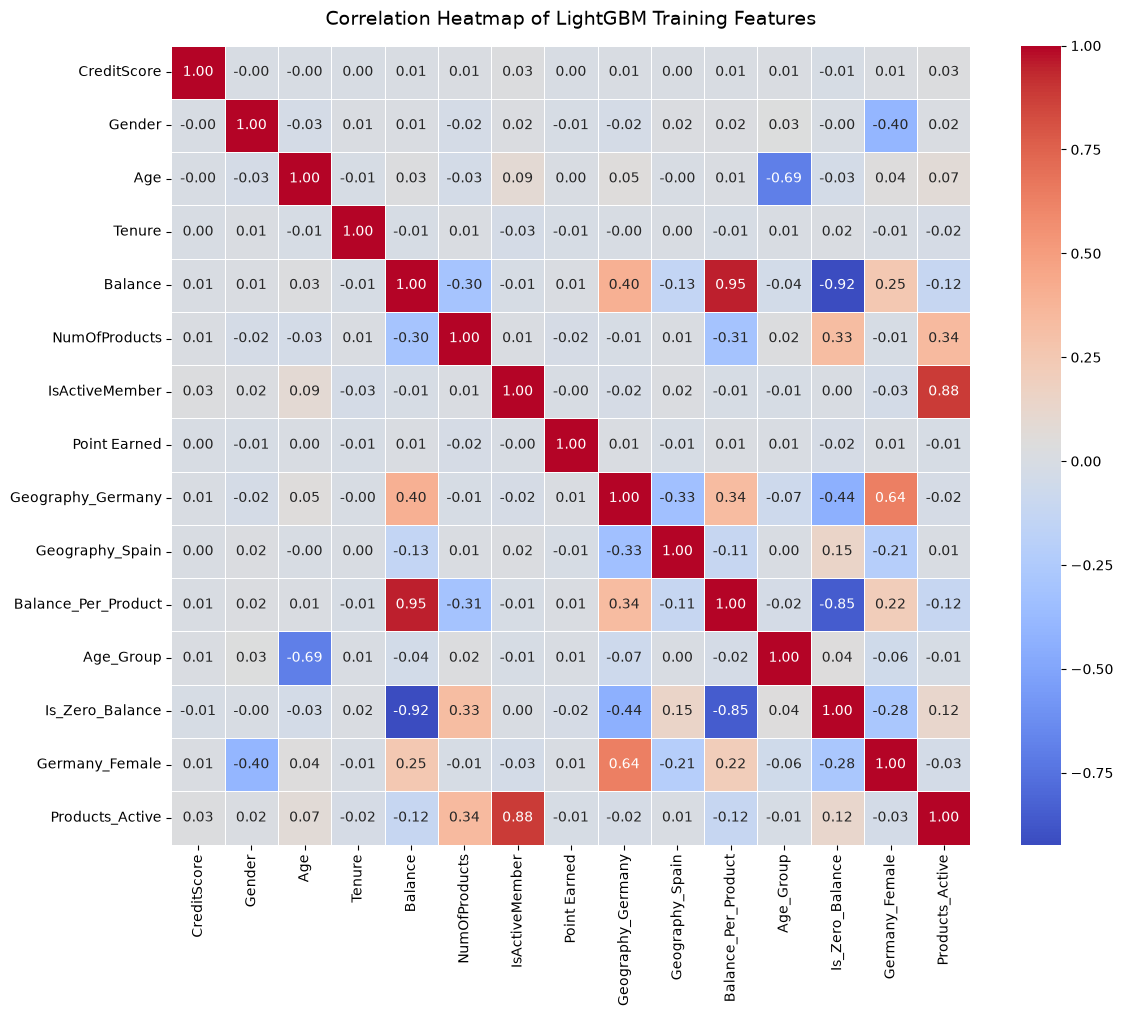

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

features_corr = X_real.corr()

sns.heatmap(
    features_corr, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    linewidths=0.5,
    square=True
)

plt.title('Correlation Heatmap of LightGBM Training Features', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [57]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
import mlflow

# 1. Drop both continuous numerical columns from features
X_dropped = X_real.drop(columns=['Age', 'Balance'])
y_real = df['Exited']

# 2. Train-Test Split with Stratification
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_dropped, y_real, test_size=0.2, random_state=42, stratify=y_real
)

# 3. Apply SMOTE to the newly dropped training set
smote = SMOTE(random_state=42)
X_train_bal_d, y_train_bal_d = smote.fit_resample(X_train_d, y_train_d)

# 4. Train LightGBM and track the experiment in MLflow
with mlflow.start_run(run_name="LightGBM_Dropped_Age_Balance"):
    lgb_model_d = LGBMClassifier(random_state=42, verbose=-1)
    lgb_model_d.fit(X_train_bal_d, y_train_bal_d)
    
    # Predict
    y_pred_d = lgb_model_d.predict(X_test_d)
    y_proba_d = lgb_model_d.predict_proba(X_test_d)[:, 1]
    
    # Evaluate
    roc_auc_d = roc_auc_score(y_test_d, y_proba_d)
    
    # Log parameters and metrics
    mlflow.log_param("model_type", "LightGBM")
    mlflow.log_param("sampling_strategy", "SMOTE")
    mlflow.log_param("action", "Dropped continuous Age and Balance columns")
    mlflow.log_metric("roc_auc", roc_auc_d)
    
    # Print Output
    print(f"LightGBM (No Age/Balance) Test ROC-AUC Score: {roc_auc_d:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test_d, y_pred_d))

LightGBM (No Age/Balance) Test ROC-AUC Score: 0.8661

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.85      0.88      1592
           1       0.55      0.72      0.62       408

    accuracy                           0.82      2000
   macro avg       0.74      0.78      0.75      2000
weighted avg       0.85      0.82      0.83      2000



In [60]:
!pip install optuna
import optuna
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import f1_score, classification_report
import mlflow

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 120),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 80),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
        'random_state': 42,
        'verbose': -1
    }
    
    model = LGBMClassifier(**params)
    
    model.fit(
        X_train_bal_d, y_train_bal_d,
        eval_set=[(X_test_d, y_test_d)],
        eval_metric='binary_logloss',
        callbacks=[early_stopping(stopping_rounds=30, verbose=False)]
    )
    
    preds = model.predict(X_test_d)
    return f1_score(y_test_d, preds)

with mlflow.start_run(run_name="LightGBM_Optuna_F1_EarlyStopping"):
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=200, timeout=600)
    
    best_params = study.best_params
    best_f1 = study.best_value
    
    final_model = LGBMClassifier(**best_params, random_state=42, verbose=-1)
    final_model.fit(
        X_train_bal_d, y_train_bal_d,
        eval_set=[(X_test_d, y_test_d)],
        eval_metric='binary_logloss',
        callbacks=[early_stopping(stopping_rounds=30, verbose=False)]
    )
    
    final_preds = final_model.predict(X_test_d)
    
    for param_name, param_value in best_params.items():
        mlflow.log_param(f"best_{param_name}", param_value)
    mlflow.log_metric("best_f1_score", best_f1)
    
    print("Optuna F1 Optimization Complete!")
    print(f"Best Test F1-Score Achieved: {best_f1:.4f}\n")
    print("Classification Report for Best Model:")
    print(classification_report(y_test_d, final_preds))


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Optuna F1 Optimization Complete!
Best Test F1-Score Achieved: 0.6303

Classification Report for Best Model:
              precision    recall  f1-score   support

           0       0.93      0.84      0.88      1592
           1       0.54      0.75      0.63       408

    accuracy                           0.82      2000
   macro avg       0.74      0.79      0.76      2000
weighted avg       0.85      0.82      0.83      2000



import joblib

# Save the freshly tuned final model from your Optuna study
joblib.dump(final_model, 'lightgbm_churn_model.pkl')

# Fit a clean scaler on the remaining numerical columns and save it
# This ensures your Streamlit app scales features exactly like the model expects
remaining_numerical_cols = ['CreditScore', 'Point Earned']
fresh_scaler = StandardScaler()
fresh_scaler.fit(X_train_d[remaining_numerical_cols])
joblib.dump(fresh_scaler, 'scaler.pkl')

print("Optimized Model and Fresh Scaler saved successfully!")
print("Features expected by the saved model:", X_dropped.columns.tolist())